# Yelp polarity: a BERT-style classifier from scratch

This adapts the embedding → attention → transformer blocks → training loop from `transformer.ipynb`. Unlike the TinyStories language model, it uses **bidirectional** attention and predicts one of two review labels from the `[CLS]` representation. There is no next-token prediction or language-model head.

Start with the **`bert-base-uncased` tokenizer vocabulary** (no pretrained model weights). Count tokens in the truncated training inputs, then save a reusable WordPiece tokenizer without tokens seen at most `RARE_TOKEN_LIMIT` times. Removed pieces may re-segment into other pieces or become `[UNK]`; this change lives in the tokenizer, not just the training data. All model weights are randomly initialized. For a quick run, the step limits below are small; set them to `None` for full epochs.

In [1]:
from itertools import islice
import time

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from datasets import load_dataset, load_from_disk
from tqdm.auto import tqdm
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() if Path('data_paths.py').is_file() else Path.cwd().parent))
from data_paths import TOKENIZERS_DIR, HF_MODELS_CACHE, load_yelp_dataset
from tokenizers import Tokenizer
from tokenizers.decoders import WordPiece as WordPieceDecoder
from tokenizers.models import WordPiece
from tokenizers.normalizers import BertNormalizer
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.processors import TemplateProcessing
from transformers import AutoTokenizer, PreTrainedTokenizerFast

MAX_LEN = 512  # includes [CLS] and [SEP]
BATCH_SIZE = 32
D_MODEL = 128
LAYERS = 3
EPOCHS = 12
MAX_TRAIN_STEPS = 100  # None = all training batches
MAX_TEST_STEPS = 30   # None = all test batches
RARE_TOKEN_LIMIT = 5  # occurrences in the inputs the model actually sees
TOKENIZE_BATCH_SIZE = 2048  # large, one-time tokenizer batches for Dataset.map
LOAD_SAVED_TOKENIZER = False  # True: skip original BERT analysis and tokenizer construction
TOKENIZER_DIR = TOKENIZERS_DIR / f'yelp_bert_pruned_tokenizer_len{MAX_LEN}_rare{RARE_TOKEN_LIMIT}'

device = (torch.accelerator.current_accelerator()
          if torch.accelerator.is_available() else torch.device('cpu'))
print(f'{device=}')

device=device(type='xpu')


## Reviews and labels

Yelp Polarity has `text` and `label` columns (0 = negative, 1 = positive). On a first run set `LOAD_SAVED_TOKENIZER = False` to measure the original BERT vocabulary and create the pruned tokenizer. On later runs set it to `True` to skip the original-tokenizer analysis and load the tokenizer plus cached tokenized train/test splits. Older tokenizer folders without split caches create them once. The final training-set coverage report still runs and reports the actual missing count (not necessarily zero). Padding is only to the longest review per training batch. Long reviews are chopped, not dropped. The `test` split is used for evaluation.

In [2]:
print('Loading Yelp Polarity...', flush=True)
dataset = load_yelp_dataset()
train_reviews = dataset['train'].select_columns(['text', 'label'])
test_reviews = dataset['test'].select_columns(['text', 'label'])
print(f'Train: {len(train_reviews):,}; test: {len(test_reviews):,}')

# Load tokenization rules only, never pretrained model weights.
if LOAD_SAVED_TOKENIZER and not (TOKENIZER_DIR / 'tokenizer.json').is_file():
    raise FileNotFoundError(f'{TOKENIZER_DIR} is missing. Run once with LOAD_SAVED_TOKENIZER=False.')
print('Loading tokenizer...', flush=True)
tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_DIR if LOAD_SAVED_TOKENIZER else 'bert-base-uncased', use_fast=True, cache_dir=str(HF_MODELS_CACHE))
VOCAB_SIZE = len(tokenizer)
PAD_ID = tokenizer.pad_token_id
assert tokenizer.cls_token_id is not None and tokenizer.sep_token_id is not None
print(f'Loaded {"saved tokenizer" if LOAD_SAVED_TOKENIZER else "original BERT tokenizer"}: {VOCAB_SIZE:,} tokens')

def tokenize_batch(batch):
    # No padding here: map runs once in large batches; collate pads at training time.
    encoded = tokenizer(batch['text'], add_special_tokens=True, truncation=False)['input_ids']
    return {
        'full_length': [len(ids) for ids in encoded],
        'input_ids': [ids if len(ids) <= MAX_LEN else ids[:MAX_LEN - 1] + [tokenizer.sep_token_id]
                      for ids in encoded],
        # Tokens displaced by truncation, excluding the retained [SEP].
        'discarded_ids': [ids[MAX_LEN - 1:-1] if len(ids) > MAX_LEN else []
                          for ids in encoded],
    }

# First pass: original BERT token IDs for counting; never consult the test split for pruning.
if not LOAD_SAVED_TOKENIZER:
    print('Tokenizing training reviews for the original vocabulary count...', flush=True)
    train_tokens = train_reviews.map(tokenize_batch, batched=True,
                                     batch_size=TOKENIZE_BATCH_SIZE, remove_columns=['text'],
                                     desc='Original BERT tokenization (train)')
    print(f'Counted {len(train_tokens):,} training reviews')

Loading Yelp Polarity...


Train: 560,000; test: 38,000
Loading tokenizer...
Loaded original BERT tokenizer: 30,522 tokens
Tokenizing training reviews for the original vocabulary count...
Counted 560,000 training reviews


## Token lengths and vocabulary coverage

The first `map` pass records original BERT token IDs and discarded IDs for **every training review**. `MAX_LEN` counts `[CLS]` and `[SEP]`; long reviews are **kept**, but tokens from the end are chopped while `[SEP]` is retained. Pruning uses only tokens **after truncation** and excludes special tokens. Full-text counts include the discarded tokens for comparison. After selecting the surviving vocabulary, both train and test are retokenized once with the saved tokenizer so their IDs agree with inference.

Computing original token lengths and coverage...


Counting training tokens:   0%|          | 0/274 [00:00<?, ?batches/s]

Reviews over MAX_LEN: 26,406/560,000 (4.7%)
Tokens removed: 5,149,932 (5.1% of all tokens including special tokens)
Length median / 90th / 95th / 99th percentile: [129.5 380.  501.  824. ]
Reviews past histogram range (1024 tokens): 2,379


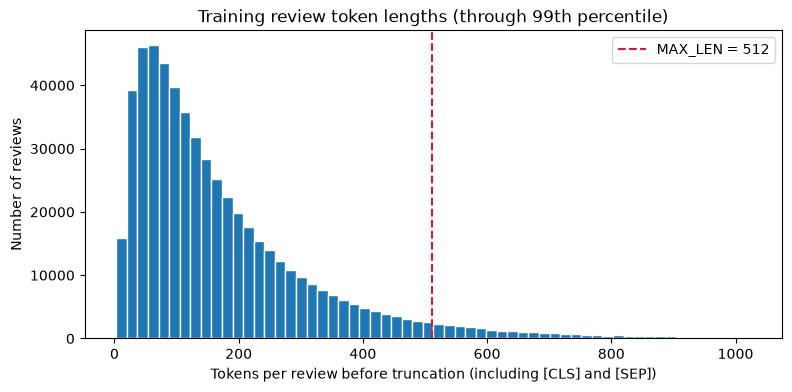

In [3]:
def count_token_ids(rows, vocab_size):
    counts = np.zeros(vocab_size, dtype=np.int64)
    discarded = np.zeros(vocab_size, dtype=np.int64)
    for batch in tqdm(rows.iter(batch_size=TOKENIZE_BATCH_SIZE),
                      total=(len(rows) + TOKENIZE_BATCH_SIZE - 1) // TOKENIZE_BATCH_SIZE,
                      desc='Counting training tokens', unit='batches'):
        counts += np.bincount(np.concatenate(batch['input_ids']).astype(np.int64, copy=False),
                              minlength=vocab_size)
        if 'discarded_ids' in batch:
            dropped = batch['discarded_ids']
            if any(dropped):
                discarded += np.bincount(np.concatenate(dropped).astype(np.int64, copy=False),
                                         minlength=vocab_size)
    return counts, discarded

if not LOAD_SAVED_TOKENIZER:
    print('Computing original token lengths and coverage...', flush=True)
    lengths = np.asarray(train_tokens['full_length'], dtype=np.int64)
    seen_counts, discarded_counts = count_token_ids(train_tokens, VOCAB_SIZE)
    full_counts = seen_counts + discarded_counts
    assert discarded_counts.sum() == np.maximum(lengths - MAX_LEN, 0).sum()
    cut = lengths > MAX_LEN
    removed = np.maximum(lengths - MAX_LEN, 0)
    print(f'Reviews over MAX_LEN: {cut.sum():,}/{len(lengths):,} ({cut.mean():.1%})')
    print(f'Tokens removed: {removed.sum():,} ({removed.sum() / lengths.sum():.1%} of all tokens including special tokens)')
    print(f'Length median / 90th / 95th / 99th percentile: {np.percentile(lengths, [50, 90, 95, 99])}')

    display_limit = max(2 * MAX_LEN, int(np.percentile(lengths, 99)))
    print(f'Reviews past histogram range ({display_limit} tokens): {(lengths > display_limit).sum():,}')
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(lengths[lengths <= display_limit], bins=60, edgecolor='white')
    ax.axvline(MAX_LEN, color='crimson', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
    ax.set(xlabel='Tokens per review before truncation (including [CLS] and [SEP])',
           ylabel='Number of reviews', title='Training review token lengths (through 99th percentile)')
    ax.legend()
    plt.show()


Original BERT tokens: 30,517 ordinary tokens
Missing after truncation: 4,137; rare (1–5): 2,618
Rare/missing vocabulary share: 22.1%
Rare occurrence share: 0.0%
[UNK] occurrence share: 0.0%
Never in full text: 4,084; lost entirely to truncation: 53
  'buccaneers': 1
  'rhineland': 1
  '##avian': 1
  'repealed': 1
  '##nesia': 1
  'crimea': 1
  '##grove': 1
  'sarawak': 1
  '##avs': 1
  'wiltshire': 1


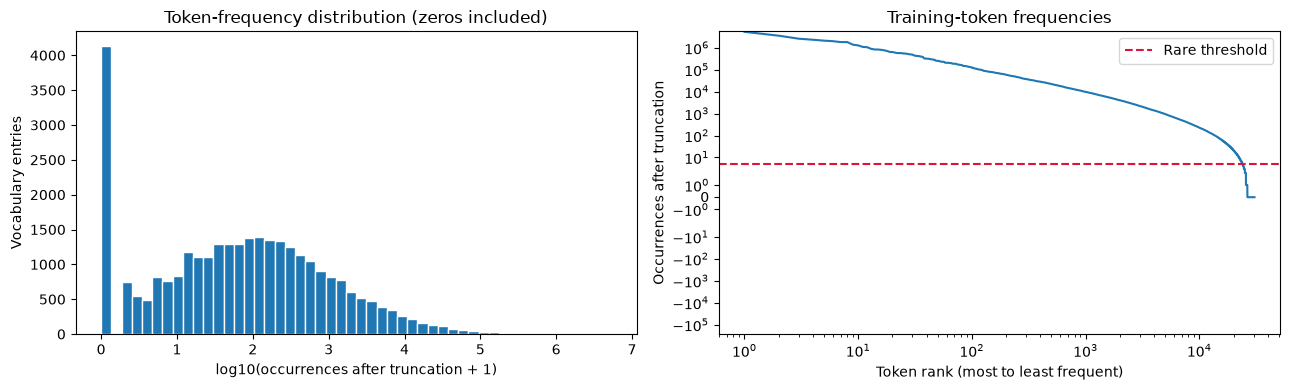

Building tokenizer without 6,755 missing/rare pieces...
Saved filtered tokenizer to yelp_bert_pruned_tokenizer_len512_rare5: 23,767 pieces
Tokenizing both splits with the saved pruned tokenizer...
Saving tokenized training split for later runs...


Saving the dataset (0/1 shards):   0%|          | 0/560000 [00:00<?, ? examples/s]

Saving tokenized test split for later runs...


Saving the dataset (0/1 shards):   0%|          | 0/38000 [00:00<?, ? examples/s]

Checking coverage on final training IDs...


Counting training tokens:   0%|          | 0/274 [00:00<?, ?batches/s]


Final training tokens (after pruning): 23,762 ordinary tokens
Missing after truncation: 0; rare (1–5): 0
Rare/missing vocabulary share: 0.0%
Rare occurrence share: 0.0%
[UNK] occurrence share: 0.0%
Batch: (32, 512); labels: [0, 1, 0, 1, 1, 0, 1, 0]


In [4]:
def report_coverage(counts, tokenizer, title, full_counts=None):
    special_ids = set(tokenizer.all_special_ids)
    ordinary_ids = np.array([i for i in range(len(tokenizer))
                             if i not in special_ids])
    used = counts[ordinary_ids]
    missing = ordinary_ids[used == 0]
    rare = ordinary_ids[(used > 0) & (used <= RARE_TOKEN_LIMIT)]
    print(f'\n{title}: {len(ordinary_ids):,} ordinary tokens')
    print(f'Missing after truncation: {len(missing):,}; rare (1–{RARE_TOKEN_LIMIT}): {len(rare):,}')
    print(f'Rare/missing vocabulary share: {(len(missing) + len(rare)) / len(ordinary_ids):.1%}')
    print(f'Rare occurrence share: {used[used <= RARE_TOKEN_LIMIT].sum() / used.sum():.1%}')
    print(f'[UNK] occurrence share: {counts[tokenizer.unk_token_id] / counts.sum():.1%}')
    if full_counts is not None:
        lost = ordinary_ids[(full_counts[ordinary_ids] > 0) & (used == 0)]
        print(f'Never in full text: {(full_counts[ordinary_ids] == 0).sum():,}; '
              f'lost entirely to truncation: {len(lost):,}')
    for tid in rare[np.argsort(counts[rare])][:10]:
        print(f'  {tokenizer.convert_ids_to_tokens(int(tid))!r}: {counts[tid]}')
    return ordinary_ids, missing, rare

if not LOAD_SAVED_TOKENIZER:
    ordinary_ids, never, rare = report_coverage(seen_counts, tokenizer,
                                              'Original BERT tokens', full_counts)
    used = seen_counts[ordinary_ids]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(np.log10(used + 1), bins=50, edgecolor='white')
    axes[0].set(xlabel='log10(occurrences after truncation + 1)',
                ylabel='Vocabulary entries', title='Token-frequency distribution (zeros included)')
    ranked = np.sort(used)[::-1]
    axes[1].plot(np.arange(1, len(ranked) + 1), ranked)
    axes[1].axhline(RARE_TOKEN_LIMIT, color='crimson', linestyle='--', label='Rare threshold')
    axes[1].set(xlabel='Token rank (most to least frequent)', ylabel='Occurrences after truncation',
                title='Training-token frequencies', xscale='log', yscale='symlog')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    # Remove missing and rare WordPiece entries from the tokenizer itself.
    removed_ids = set(never) | set(rare)
    print(f'Building tokenizer without {len(removed_ids):,} missing/rare pieces...', flush=True)
    bert_vocab = tokenizer.get_vocab()
    kept_pieces = [piece for piece, old_id in sorted(bert_vocab.items(), key=lambda pair: pair[1])
                   if old_id not in removed_ids]
    if not (TOKENIZER_DIR / 'tokenizer.json').exists():
        backend = Tokenizer(WordPiece(vocab={piece: i for i, piece in enumerate(kept_pieces)},
                                      unk_token='[UNK]'))
        backend.normalizer = BertNormalizer(lowercase=True)
        backend.pre_tokenizer = BertPreTokenizer()
        backend.decoder = WordPieceDecoder()
        backend.post_processor = TemplateProcessing(
            single='[CLS] $A [SEP]',
            special_tokens=[('[CLS]', backend.token_to_id('[CLS]')),
                            ('[SEP]', backend.token_to_id('[SEP]'))])
        pruned = PreTrainedTokenizerFast(tokenizer_object=backend,
            pad_token='[PAD]', unk_token='[UNK]', cls_token='[CLS]',
            sep_token='[SEP]', mask_token='[MASK]', model_max_length=MAX_LEN)
        pruned.save_pretrained(TOKENIZER_DIR)
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR, use_fast=True)
    VOCAB_SIZE = len(tokenizer)
    PAD_ID = tokenizer.pad_token_id
    # One get_vocab() call, not a new 30k-entry dictionary for every token.
    expected_vocab = {piece: i for i, piece in enumerate(kept_pieces)}
    assert tokenizer.get_vocab() == expected_vocab, 'Saved tokenizer differs from this pruning run'
    print(f'Saved filtered tokenizer to {TOKENIZER_DIR}: {VOCAB_SIZE:,} pieces')

# Retokenize BOTH splits with the saved tokenizer: deleting WordPiece entries can
# change segmentation, so substituting old integer IDs would disagree with inference.
def tokenize_final(batch):
    return {'input_ids': tokenizer(batch['text'], truncation=True,
                                   max_length=MAX_LEN)['input_ids']}

train_cache = TOKENIZER_DIR / 'train_tokens'
test_cache = TOKENIZER_DIR / 'test_tokens'
if LOAD_SAVED_TOKENIZER and train_cache.is_dir() and test_cache.is_dir():
    print('Loading saved train/test token IDs...', flush=True)
    train_tokens = load_from_disk(str(train_cache))
    test_tokens = load_from_disk(str(test_cache))
    print('Loaded cached train/test token IDs')
else:
    print('Tokenizing both splits with the saved pruned tokenizer...', flush=True)
    train_tokens = train_reviews.map(tokenize_final, batched=True,
                                     batch_size=TOKENIZE_BATCH_SIZE, remove_columns=['text'],
                                     desc='Pruned tokenization (train)')
    test_tokens = test_reviews.map(tokenize_final, batched=True,
                                   batch_size=TOKENIZE_BATCH_SIZE, remove_columns=['text'],
                                   desc='Pruned tokenization (test)')
    if not train_cache.exists():
        print('Saving tokenized training split for later runs...', flush=True)
        train_tokens.save_to_disk(str(train_cache))
    if not test_cache.exists():
        print('Saving tokenized test split for later runs...', flush=True)
        test_tokens.save_to_disk(str(test_cache))
assert len(train_tokens) == len(train_reviews) and len(test_tokens) == len(test_reviews)
print('Checking coverage on final training IDs...', flush=True)
final_counts, _ = count_token_ids(train_tokens, VOCAB_SIZE)
report_coverage(final_counts, tokenizer, 'Final training tokens (after pruning)')
assert max(map(len, train_tokens[:BATCH_SIZE]['input_ids'])) <= MAX_LEN
assert max(map(len, test_tokens[:BATCH_SIZE]['input_ids'])) <= MAX_LEN

def collate_fn(examples):
    width = max(len(item['input_ids']) for item in examples)
    ids = torch.full((len(examples), width), PAD_ID, dtype=torch.long)
    labels = torch.tensor([item['label'] for item in examples], dtype=torch.long)
    for row, item in enumerate(examples):
        tokens = item['input_ids']
        ids[row, :len(tokens)] = torch.tensor(tokens, dtype=torch.long)
    return ids, labels

train_loader = DataLoader(train_tokens, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, pin_memory=device.type != 'cpu')
test_loader = DataLoader(test_tokens, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, pin_memory=device.type != 'cpu')
ids, labels = next(iter(train_loader))
assert labels.shape == (ids.shape[0],)
assert (ids[:, 0] == tokenizer.cls_token_id).all()
print(f'Batch: {tuple(ids.shape)}; labels: {labels[:8].tolist()}')

## Bidirectional encoder

Like the original notebook this is a small, single-head transformer built explicitly from PyTorch layers, **not** a downloaded `BertModel`. It is BERT-style (not an exact BERT-base architecture): attention has **no causal or padding mask**. `[CLS]` collects information for the two-class head. Because batches are padded, unmasked attention can also see padding tokens; this is a deliberate consequence of removing all masks, not standard BERT padding behavior.

In [5]:
def attention_math(q, k, v, scale):
    scores = (q @ k.transpose(-2, -1)) * scale  # transpose is for attention, not loss
    return torch.softmax(scores, dim=-1) @ v

class Attention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.scale = d ** -0.5

    def forward(self, x):
        return attention_math(self.q(x), self.k(x), self.v(x), self.scale)

class Embed(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.tok = nn.Embedding(VOCAB_SIZE, d, padding_idx=PAD_ID)
        self.pos = nn.Embedding(MAX_LEN, d)
        self.dropout = nn.Dropout(0.1)

    def forward(self, ids):
        positions = torch.arange(ids.shape[1], device=ids.device)
        return self.dropout(self.tok(ids) + self.pos(positions))

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attention = Attention(d)
        self.norm2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class BertStyleClassifier(nn.Module):
    def __init__(self, d, layers):
        super().__init__()
        self.embed = Embed(d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, 2)

    def forward(self, ids):
        x = self.embed(ids)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))  # one [CLS] prediction per review

model = BertStyleClassifier(D_MODEL, LAYERS).to(device)
print(f'Randomly initialized parameters: {sum(p.numel() for p in model.parameters()):,}')

Randomly initialized parameters: 3,652,354


## Classification loss and training

`F.cross_entropy` applies log-softmax internally. The class dimension is already last in `[batch, 2]`, so reshape to `[-1, 2]` rather than transposing logits (and labels to `[-1]`). This does not create a `[batch, length, vocab]` language-model output. The test split is evaluated only, not trained on.

In [6]:
def run_epoch(model, loader, opt=None, max_steps=None, loss_history=None):
    training = opt is not None
    model.train(training)
    total_loss = total_correct = total_examples = 0
    count = min(len(loader), max_steps) if max_steps is not None else len(loader)
    start = time.perf_counter()
    with torch.set_grad_enabled(training):
        for host_ids, host_labels in tqdm(islice(loader, max_steps), total=count):
            ids = host_ids.to(device, non_blocking=True)
            labels = host_labels.to(device, non_blocking=True)
            if training:
                opt.zero_grad()
            logits = model(ids)
            loss = F.cross_entropy(logits.reshape(-1, 2), labels.reshape(-1))
            if training:
                loss.backward()
                opt.step()
            if training and loss_history is not None:
                loss_history.append(loss.item())  # one point per optimizer step
            n = labels.numel()
            total_loss += loss.item() * n
            total_correct += (logits.argmax(dim=-1) == labels).sum().item()
            total_examples += n
    return {'loss': total_loss / total_examples,
            'accuracy': total_correct / total_examples,
            'examples': total_examples, 'seconds': time.perf_counter() - start}

# Check output shape and backward pass before training.
ids, labels = next(iter(train_loader))
logits = model(ids.to(device))
assert logits.shape == (len(labels), 2)
F.cross_entropy(logits.reshape(-1, 2), labels.to(device).reshape(-1)).backward()
model.zero_grad(set_to_none=True)
print('Classifier forward/backward check passed')

Classifier forward/backward check passed


In [7]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
train_losses = []
test_points = []
for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_result = run_epoch(model, train_loader, opt, MAX_TRAIN_STEPS, train_losses)
    print('train:', train_result)
    test_result = run_epoch(model, test_loader, max_steps=MAX_TEST_STEPS)
    print('test:', test_result)
    test_points.append((len(train_losses), test_result['loss']))

Epoch 1/12


  0%|          | 0/100 [00:00<?, ?it/s]

train: {'loss': 0.7002499860525131, 'accuracy': 0.526875, 'examples': 3200, 'seconds': 9.191428299993277}


  0%|          | 0/30 [00:00<?, ?it/s]

test: {'loss': 0.6884835004806519, 'accuracy': 0.5385416666666667, 'examples': 960, 'seconds': 0.7349560996517539}
Epoch 2/12


...

test: {'loss': 0.3727054506540298, 'accuracy': 0.8322916666666667, 'examples': 960, 'seconds': 0.7932131998240948}
Epoch 12/12


  0%|          | 0/100 [00:00<?, ?it/s]

train: {'loss': 0.37900213614106176, 'accuracy': 0.835625, 'examples': 3200, 'seconds': 7.331964500248432}


  0%|          | 0/30 [00:00<?, ?it/s]

test: {'loss': 0.3655237153172493, 'accuracy': 0.8333333333333334, 'examples': 960, 'seconds': 0.7896569999866188}


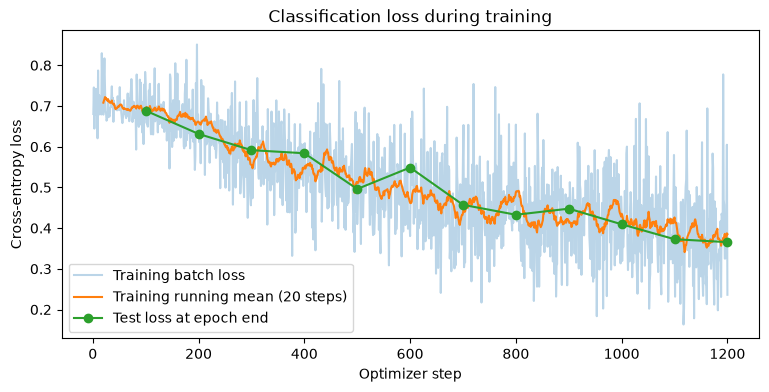

In [8]:
# Raw per-batch training loss and test loss at each epoch boundary.
# The thin raw line shows noise; the thick line is a running mean for readability.
steps = np.arange(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, train_losses, alpha=0.3, label='Training batch loss')
window = min(20, len(train_losses))
if window:
    smoothed = np.convolve(train_losses, np.ones(window) / window, mode='valid')
    ax.plot(steps[window - 1:], smoothed, label=f'Training running mean ({window} steps)')
if test_points:
    test_steps, test_losses = zip(*test_points)
    ax.plot(test_steps, test_losses, 'o-', label='Test loss at epoch end')
ax.set(xlabel='Optimizer step', ylabel='Cross-entropy loss', title='Classification loss during training')
ax.legend()
plt.show()